# CricFit AI — Yo-Yo Test Shuttle & Cadence Analysis Pipeline (v2)

**v2 change:** v1 treated the Yo-Yo test as continuous running-in-place and tracked
only vertical ankle bob. That's wrong — the real test is 20m shuttle runs with
turns and mandatory 10s rest walks between them, at increasing speed each level.

**This version:**
1. Tracks **both** horizontal hip position (to find shuttle turns/rests) and
   vertical ankle position (to count steps) per frame.
2. Segments the clip into running legs vs rest-walks using an actual movement
   **speed** threshold, not naive peak-picking — so standing at a cone isn't
   mistaken for part of a run.
3. Reports cadence **per shuttle**, a shuttle-over-shuttle fatigue trend, and
   rest-window compliance (flags if a return-to-line took > 10s).
4. Looks up real distance/speed for the reported `level.shuttle` score from
   the official Yo-Yo IR1 protocol table (Bangsbo, Iaia & Krustrup, 2008) —
   no more fabricated `distance / time` average speed.
5. The actual production logic (`cadence_tracker.py`) is written to disk and
   imported here directly (see step 3 below), so the notebook and the module
   that ships to the FastAPI backend can never drift out of sync.

**Flow:**
1. Write + import the validated `ShuttleCadenceTracker` module
2. Manual input — the reported `level.shuttle` score + target benchmark
3. Upload a test video (**side-on shuttle run between two cones**, not
   running in place)
4. Run MediaPipe Pose → extract ankle-y (steps) + hip-x (shuttle position)
5. Visualize both trajectories (sanity check before trusting anything)
6. Run shuttle/rest segmentation → tune thresholds here if it looks off
7. Build the final JSON report → this is what gets sent to Groq for tips


## 1. Install dependencies

In [1]:
!pip install -q mediapipe opencv-python-headless scipy numpy matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 8.4 MB/s eta 0:00:00


## 2. Download the MediaPipe Pose Landmarker model (Tasks API)

Using `pose_landmarker_lite` — same model choice as the rest of the CricFit
pipelines, for compatibility with the Tasks API.

In [2]:
!wget -q -O pose_landmarker_lite.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task
print('Model downloaded.')


Model downloaded.


## 3. Write + import the validated cadence tracker module

This is the **exact same file** that ships to the FastAPI backend — writing
it here (instead of re-typing the logic) means tuning done in this notebook
and the production module never drift apart.

In [3]:
%%writefile cadence_tracker.py
"""
CricFit AI - Yo-Yo Test Shuttle & Cadence Tracker  (v2.3)

WHY THIS WAS REWRITTEN
-----------------------
v1 modeled the Yo-Yo test as "player running in place" and tracked ankle
Y-position (vertical bob) for the whole clip, then divided total distance by
total time for an "avg speed", and split the whole clip into 3 equal TIME
windows to detect a fatigue trend.

That's wrong because a Yo-Yo test is NOT continuous running in place:
  - Player sprints 20m out, turns, sprints 20m back, then WALKS for a
    mandatory ~10s recovery, then the beep forces the next (faster) shuttle.
  - Speed is not constant - it increases every level. distance/time over the
    whole session is not a real pace, it's diluted by rest-walks.
  - "Fatigue" only makes sense compared shuttle-to-shuttle, not across
    arbitrary equal time-thirds that mix running and resting unevenly.

v2 instead:
  1. Tracks the player's **apparent body scale** (shoulder-to-hip distance in
     the frame) to find the two turn-lines and segment the clip into:
     running legs / turns / rest-walks. This works whether the camera is
     side-on (lateral motion) OR facing straight down the running lane
     (which is how most people naturally film it, phone in hand, standing
     at the start line) - body scale shrinks/grows as the player gets
     farther/closer regardless of which way they're actually moving in the
     frame, unlike raw horizontal position which only works side-on.
  2. Only computes step cadence (vertical bob) *inside* running legs.
  3. Groups legs into shuttles (out+back = 1 shuttle) and computes
     cadence/pace per shuttle, so trend = shuttle-over-shuttle, not
     arbitrary time-thirds.
  4. Flags rest-window compliance (real Yo-Yo tests fail you if you don't
     get back to the line before the 10s countdown ends).
  5. Does NOT compute a fake "avg_speed_mps" from manual distance/time.
     Distance/speed for a given level.shuttle score is looked up from the
     official Yo-Yo IR1 protocol table (Bangsbo, Iaia & Krustrup, 2008),
     see YOYO_IR1_LEVEL_TABLE below. Table covers scores up to 23.8/3640m;
     anything beyond that returns an explicit "outside tabulated range"
     note rather than a guess.
  6. Cross-checks the video-detected shuttle count against how many
     shuttles the reported score implies should have happened - catches
     clips that start mid-test or cut off early.

v2.1 CHANGES (bug fixes)
------------------------
  a. Rest-compliance direction was INVERTED. The beep schedule is
     40m / level-speed + 10s recovery, so a player at-or-above beep pace
     produces gaps >= ~10s. A gap notably UNDER 10s means the player was
     LATE back to the line (the violation); gaps OVER 10s are fine (early
     finisher idling until the next beep). Fixed the check + note.
  b. Recovery windows are now measured directly between the end of each
     back-leg and the start of the next out-leg. Previously they were taken
     from the segmentation 'rests' list, which also contained the idle wait
     before the first sprint, the tail after the last one, and cone-turn
     pauses - all of which polluted the compliance check.
  c. analyze_video_file() now raises a clear error if the video can't be
     opened, instead of silently producing a junk all-zeros report.
  d. Step-peak prominence is now adaptive per leg (scaled to that leg's own
     ankle-bob amplitude, with a floor), replacing the fixed default that
     needed per-clip manual tuning.
  e. Tracks how many frames had no detected pose and reports it - frames
     without a pose are excluded from all series, and a high drop rate
     explains downstream index/label mismatches.
  f. __main__ takes yoyo_level / target score as CLI args instead of
     hardcoded values.

v2.3 CHANGES (fixes cadence/steps showing 0 on real footage)
------------------------------------------------------------------
Root cause: step counting averaged left-ankle-y and right-ankle-y together.
During running the two ankles bob in OPPOSITE phase (one plants while the
other swings) - averaging two opposite-phase signals cancels almost all of
the real signal, leaving only the much smaller whole-body bounce plus
landmark jitter. Confirmed with a synthetic gait signal before shipping:
the averaged signal's peak-to-peak amplitude collapsed to roughly the noise
floor (and worse, occasionally still found a few "steps" out of pure
noise - silently wrong rather than obviously broken).
  i. Now tracks left-ankle-y MINUS right-ankle-y instead of their average.
     This preserves the alternating step signal at roughly 10x the
     amplitude in testing. Both directions of extrema in this difference
     signal are counted as steps (one footfall each), not just one.
v2.2 CHANGES (fixes real sprint frames being mislabeled RESTING)
------------------------------------------------------------------
Root cause found by reviewing yoyo_demo_whatsapp.mp4 frame-by-frame: the
overlay label was index-aligned correctly (that was already fixed in
v2.1), but the *segmentation itself* was misclassifying genuine sprinting
as rest, on both toward/away-camera and side-on footage:

  g. Turn-point detection was running on the same LIGHTLY-smoothed signal
     used for rate calculation. Running gait causes body_scale (and to a
     lesser extent hip_x) to wobble every stride - arm swing and torso
     rotation change the shoulder-hip projection independent of real
     distance/position change. That wobble was getting picked up by
     find_peaks() as fake turn-points mid-sprint, chopping one real leg
     into several short fragments, each too brief/low-displacement to
     clear LEG_AVG_RATE_THRESHOLD or MIN_LEG_DURATION_SEC on its own - so
     they fell through to "rest". This was worst early/close to camera,
     where gait wobble is a larger fraction of the frame than it is once
     the player is far away.
     Fix: turn-points are now found on a SEPARATE, more heavily smoothed
     copy of the signal (TURN_POINT_SMOOTH_WINDOW_SEC), with a minimum
     spacing between accepted peaks (TURN_POINT_MIN_SPACING_SEC) so gait
     noise can no longer register as a turn. The lightly-smoothed signal
     is still used for the actual rate/displacement math, so short real
     legs aren't blurred away either - two different smoothing windows
     for two different jobs, instead of one window trying to do both.
  h. Rate-per-candidate-segment was computed from just the two endpoint
     samples (displacement between a and b, divided by duration). A
     single noisy endpoint sample (mid-gait-cycle, arbitrary phase) could
     understate a real sprint's rate enough to fail the threshold - this
     hit hardest at the LAST segment before the clip ends, since that
     endpoint is an arbitrary video cutoff, not a real turn, so it's not
     an extremum and is more exposed to single-sample noise than an
     interior turn-point is.
     Fix: rate is now a least-squares slope over every sample in the
     candidate span (see _segment_rate), not a two-point difference - one
     noisy sample can no longer flip a real sprint into a false "rest".

Requires: opencv-python, mediapipe, numpy, scipy
Also requires pose_landmarker_lite.task in the working directory.
"""

import time
import json
from datetime import datetime, timezone

import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from scipy.signal import find_peaks

LEFT_ANKLE, RIGHT_ANKLE = 27, 28
LEFT_HIP, RIGHT_HIP = 23, 24
LEFT_SHOULDER, RIGHT_SHOULDER = 11, 12

DEFAULT_MODEL_PATH = "pose_landmarker_lite.task"

# --- test-structure constants (fixed by the Yo-Yo IR1 protocol itself) ---
SHUTTLE_LEG_M = 20.0          # one-way distance between the two lines
REST_WINDOW_SEC = 10.0        # mandatory recovery window between shuttles

# v2.1: how far under the 10s window a recovery gap can fall before it is
# counted as "late back to the line". Absorbs frame-quantization + pose
# jitter around the turn moment. NOT part of the official protocol - a
# measurement-noise allowance only.
LATE_TOLERANCE_SEC = 1.5

# --- tuning knobs, same role as v1, re-tuned per motion axis ---
MIN_STEP_INTERVAL_SEC = 0.25

# v2.1: replaces the old fixed STEP_PEAK_PROMINENCE (0.01), which needed
# per-clip manual tuning and produced 0-2 steps on real sprints when too
# high. Prominence is now scaled per leg to that leg's own ankle-bob
# amplitude (see _cadence_in_range); this floor only kicks in for legs with
# an almost-flat bob (e.g. very distant camera), where nothing meaningful
# can be detected anyway.
CADENCE_PROMINENCE_FLOOR = 0.004

# --- segmentation knobs (extrema + average-rate based - see _segment_movement) ---
SIGNAL_SMOOTH_WINDOW_SEC = 0.2     # LIGHT smoothing, just to stop landmark
                                    # jitter creating spurious tiny peaks -
                                    # deliberately much shorter than a real
                                    # leg (~1-1.5s). A wider window (v2's
                                    # original 0.6s, used for instantaneous
                                    # velocity thresholding) blurred real
                                    # legs below the moving threshold, which
                                    # was the actual cause of 0 legs detected
                                    # on real footage - fixed by dropping
                                    # instantaneous-velocity classification
                                    # entirely in favor of per-leg avg rate.

# v2.2: SEPARATE, heavier smoothing used ONLY to find turn-points (not for
# rate calc - see SIGNAL_SMOOTH_WINDOW_SEC above, which stays light so real
# short legs aren't blurred). This is v2's original 0.6s window, repurposed:
# it's fine for turn-point finding to blur across a stride-cycle (a real
# turn is one event lasting well over a full gait cycle), it was only wrong
# when used for the rate math itself.
TURN_POINT_SMOOTH_WINDOW_SEC = 0.6

# v2.2: minimum spacing (seconds) enforced between accepted turn-points via
# find_peaks(distance=...). A real out-leg or back-leg takes >= ~1s even at
# the fastest levels (see MIN_LEG_DURATION_SEC) - two "turns" closer than
# that are gait wobble, not two real direction changes, and were the main
# source of a real sprint getting chopped into rest-classified fragments.
TURN_POINT_MIN_SPACING_SEC = 1.0
LEG_AVG_RATE_THRESHOLD = 0.06      # body-scale units/sec, averaged over a
                                    # whole candidate leg (displacement /
                                    # duration) - NOT an instantaneous/
                                    # smoothed derivative. Distinguishes a
                                    # sprint leg from the slower rest-walk
                                    # between two turn points, both of which
                                    # are found the same way (local extrema
                                    # of body_scale). Tune per camera
                                    # distance/framing: too low = rest-walk
                                    # counted as a leg, too high = a genuine
                                    # but shorter/farther-out leg misses it.
MIN_REST_DURATION_SEC = 1.5        # a "paused" stretch shorter than this is
                                    # just the cone turn, not the 10s recovery
MIN_LEG_DISPLACEMENT = 0.03        # body-scale distance a "moving" segment
                                    # must cover to count as a real leg, not
                                    # camera jitter or a stumble-in-place -
                                    # smaller than the old x-position value
                                    # since torso-length change per leg is a
                                    # smaller quantity than a full-frame
                                    # horizontal traverse
MIN_LEG_DURATION_SEC = 1.0          # a real 20m sprint leg takes at least
                                    # ~1-1.5s even at the fastest levels -
                                    # anything shorter that still cleared the
                                    # displacement check is a noise blip, not
                                    # an actual leg. This is what was missing
                                    # before: displacement alone let a brief
                                    # jittery spike count as a "leg" even
                                    # though no real runner moves that fast

# Yo-Yo IR1 protocol table, adapted from Bangsbo, Iaia & Krustrup (2008),
# "The Yo-Yo Intermittent Recovery Test: A Useful Tool for Evaluation of
# Physical Performance in Intermittent Sports", Sports Med 38(1):37-51.
# Each speed level has N shuttles (2 x 20m each) at a fixed speed before the
# next speed step. The reported score "16.3" means speed level 16, 3rd
# shuttle at that speed -> keyed here as (speed_level, shuttle_in_level).
_YOYO_IR1_SPEED_STAGES = [
    # (speed_level, shuttles_in_level, speed_kmh)
    (5, 1, 10.0),
    (9, 1, 12.0),
    (11, 2, 13.0),
    (12, 3, 13.5),
    (13, 4, 14.0),
    (14, 8, 14.5),
    (15, 8, 15.0),
    (16, 8, 15.5),
    (17, 8, 16.0),
    (18, 8, 16.5),
    (19, 8, 17.0),
    (20, 8, 17.5),
    (21, 8, 18.0),
    (22, 8, 18.5),
    (23, 8, 19.0),
]

def _build_yoyo_ir1_table():
    table = {}
    global_shuttle_count = 0
    for speed_level, n_shuttles, speed_kmh in _YOYO_IR1_SPEED_STAGES:
        for shuttle_in_level in range(1, n_shuttles + 1):
            global_shuttle_count += 1
            table[(speed_level, shuttle_in_level)] = {
                "speed_kmh": speed_kmh,
                "distance_m": global_shuttle_count * 40,  # 2 x 20m per shuttle
                "cumulative_shuttle_number": global_shuttle_count,
            }
    return table

YOYO_IR1_LEVEL_TABLE = _build_yoyo_ir1_table()
# Table covers up to score 23.8 / 3640m (elite-range). Scores beyond that
# aren't in the published protocol table and will return a "beyond tabulated
# range" note rather than a guessed number.


def _parse_level_shuttle(yoyo_level: str):
    """'16.3' -> (16, 3). Returns None if it doesn't parse as level.shuttle."""
    try:
        text = str(yoyo_level).strip()
        speed_level_str, shuttle_str = text.split(".")
        return int(speed_level_str), int(shuttle_str)
    except (ValueError, AttributeError):
        return None


def _lookup_level_reference(yoyo_level: str):
    """Looks up speed/distance for a reported level.shuttle score against the
    Yo-Yo IR1 protocol table. Returns explicit None + note on anything that
    doesn't resolve, rather than guessing."""
    if yoyo_level is None:
        return {"speed_kmh": None, "distance_m": None,
                "cumulative_shuttle_number": None, "note": "no yoyo_level given"}

    parsed = _parse_level_shuttle(yoyo_level)
    if parsed is None:
        return {"speed_kmh": None, "distance_m": None,
                "cumulative_shuttle_number": None,
                "note": f"'{yoyo_level}' isn't in level.shuttle format (e.g. '16.3')"}

    entry = YOYO_IR1_LEVEL_TABLE.get(parsed)
    if entry is None:
        return {"speed_kmh": None, "distance_m": None,
                "cumulative_shuttle_number": None,
                "note": f"score {yoyo_level} is outside the tabulated YYIR1 "
                        f"range (table covers up to 23.8 / 3640m) - "
                        f"double check the reported score"}
    return {**entry, "note": None}


class ShuttleCadenceTracker:
    """
    Feed it frames (live or looped over a video), then call finalize() once
    the test session is over.

    Unlike v1, this does NOT assume continuous in-place running: it segments
    the session into running legs / turns / rest-walks first, and only
    reports cadence for the running legs.

    Note: frames where MediaPipe finds no pose are skipped entirely - all
    internal series (timestamps included) are indexed by DETECTED frames,
    not by raw video frames. Anything indexing into these series must count
    detected frames, not raw frame numbers.
    """

    def __init__(self, model_path: str = DEFAULT_MODEL_PATH):
        options = mp_vision.PoseLandmarkerOptions(
            base_options=mp_python.BaseOptions(model_asset_path=model_path),
            running_mode=mp_vision.RunningMode.VIDEO,
            num_poses=1,
        )
        self._landmarker = mp_vision.PoseLandmarker.create_from_options(options)
        self._start_time = None
        self._ankle_y_series = []
        # v2.3: left-minus-right ankle-y, NOT the average. During running the
        # two ankles bob in OPPOSITE phase (one plants while the other
        # swings) - averaging them cancels almost the entire step signal,
        # leaving only the much smaller whole-body center-of-mass bounce
        # plus landmark jitter. That's what was producing 0 detected steps
        # on real footage: ptp(avg) was collapsing to near the noise floor.
        # The left-right DIFFERENCE preserves the alternating signal at
        # roughly 10x the amplitude (confirmed against a synthetic gait
        # signal before shipping - see debugging notes) and is what
        # _cadence_in_range now uses; _ankle_y_series is kept only for any
        # existing diagnostics/plots that reference it.
        self._ankle_diff_series = []
        self._hip_x_series = []        # horizontal position - informative for
                                        # side-on filming (lateral runs)
        self._body_scale_series = []   # apparent body size - informative for
                                        # end-on filming (toward/away runs)
        self._timestamps_sec = []
        self._frames_processed = 0     # v2.1: all frames fed in, pose or not
        self._closed = False
        self._last_signal_used = None

    def start(self):
        self._start_time = time.time()

    def process_frame(self, frame_bgr: np.ndarray, timestamp_ms: int = None) -> dict:
        if self._start_time is None:
            self.start()
        if timestamp_ms is None:
            timestamp_ms = int((time.time() - self._start_time) * 1000)

        # v2.1: count every frame fed in, so finalize() can report the
        # pose-detection drop rate.
        self._frames_processed += 1

        rgb_frame = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        result = self._landmarker.detect_for_video(mp_image, timestamp_ms)

        if result.pose_landmarks:
            lm = result.pose_landmarks[0]
            avg_ankle_y = (lm[LEFT_ANKLE].y + lm[RIGHT_ANKLE].y) / 2.0
            ankle_diff = lm[LEFT_ANKLE].y - lm[RIGHT_ANKLE].y  # v2.3: see __init__ note
            avg_hip_x = (lm[LEFT_HIP].x + lm[RIGHT_HIP].x) / 2.0
            # torso length (shoulder-to-hip distance) as a proxy for distance
            # from camera: shrinks as the player runs away, grows as they run
            # toward the camera. Track both this and hip-x - whichever one
            # actually varies over the session tells us which way the camera
            # was pointed, without needing to ask upfront.
            left_torso = np.hypot(lm[LEFT_SHOULDER].x - lm[LEFT_HIP].x,
                                   lm[LEFT_SHOULDER].y - lm[LEFT_HIP].y)
            right_torso = np.hypot(lm[RIGHT_SHOULDER].x - lm[RIGHT_HIP].x,
                                    lm[RIGHT_SHOULDER].y - lm[RIGHT_HIP].y)
            body_scale = (left_torso + right_torso) / 2.0
            self._ankle_y_series.append(avg_ankle_y)
            self._ankle_diff_series.append(ankle_diff)
            self._hip_x_series.append(avg_hip_x)
            self._body_scale_series.append(body_scale)
            self._timestamps_sec.append(timestamp_ms / 1000.0)

        return self._live_stats()

    def _select_motion_signal(self) -> np.ndarray:
        """Picks whichever tracked signal (hip-x or body-scale) actually
        shows real movement over the session, so the same code handles
        side-on footage (hip-x varies) and end-on footage - camera facing
        down the running lane (body-scale varies) without needing to be
        told which one was used to film."""
        x = np.array(self._hip_x_series)
        scale = np.array(self._body_scale_series)
        if len(x) < 3:
            return x
        # normalize each to its own typical size so a comparison across the
        # two different units (frame-width fraction vs torso-length fraction)
        # is fair, then use whichever has the larger overall swing.
        x_range = np.ptp(x) / (np.mean(x) + 1e-6)
        scale_range = np.ptp(scale) / (np.mean(scale) + 1e-6)
        self._last_signal_used = "hip_x (side-on)" if x_range >= scale_range else "body_scale (toward/away)"
        return x if x_range >= scale_range else scale

    def _estimated_fps(self) -> float:
        if len(self._timestamps_sec) < 2:
            return 30.0
        duration = self._timestamps_sec[-1] - self._timestamps_sec[0]
        return (len(self._timestamps_sec) - 1) / duration if duration > 0 else 30.0

    def _live_stats(self) -> dict:
        if len(self._body_scale_series) < 2:
            return {"legs_so_far": 0, "elapsed_sec": 0.0}
        signal = self._select_motion_signal()
        legs, _ = self._segment_movement(signal, np.array(self._timestamps_sec))
        elapsed = self._timestamps_sec[-1] - self._timestamps_sec[0]
        return {
            "legs_so_far": len(legs),
            "elapsed_sec": round(float(elapsed), 1),
        }

    # v2.2: robust rate/direction for one candidate span, replacing the old
    # (smoothed[b] - smoothed[a]) / duration two-point difference. A
    # two-point difference lives or dies on exactly two samples; if either
    # one lands on a noisy point in the running-gait cycle (arm swing/torso
    # rotation shifting body_scale independent of real translation), a
    # genuine sprint's measured rate can come out near zero. This hit the
    # LAST leg of a clip hardest, since its end (n-1) is an arbitrary video
    # cutoff, not a real turn-point extremum, so it has no reason to land on
    # a "clean" phase of the gait cycle the way a detected extremum usually
    # does. A least-squares slope over every sample in the span uses all the
    # data instead of two arbitrary points, so one noisy sample can't flip a
    # real sprint into a false "rest" classification.
    def _segment_rate(self, signal_window: np.ndarray, time_window: np.ndarray):
        if len(time_window) < 2:
            return 0.0, 1
        slope = float(np.polyfit(time_window, signal_window, 1)[0])
        direction = 1 if slope >= 0 else -1
        return abs(slope), direction

    # v2.2: a REST->next-leg boundary is a SPEED change, not a DIRECTION
    # change (the player already turned at the far/near line; the rest-walk
    # continues a beat in roughly the same heading as the sprint that
    # follows it). Pure extrema detection can only ever find direction
    # reversals, so this boundary never shows up as a turn-point - a long
    # rest is followed immediately by a real leg with no extremum between
    # them, and the two get evaluated together as one span whose average
    # rate is diluted below LEG_AVG_RATE_THRESHOLD by the rest portion, so
    # a genuine sprint at the end of that span was falling through to
    # "rest" entirely undetected. Confirmed against synthetic
    # rest-then-sprint data before shipping this - see debugging notes.
    # This scans a span that failed the whole-span rate test for a point
    # where a trailing sub-window's rate clears the threshold and stays
    # cleared through the end of the span, and returns that as a synthetic
    # split point.
    def _refine_span(self, a, b, smoothed, timestamps, fps):
        duration = timestamps[b] - timestamps[a]
        if duration < 2 * MIN_LEG_DURATION_SEC:
            return None
        win = max(2, int(MIN_LEG_DURATION_SEC * fps))
        step = max(1, win // 4)
        for start in range(a, b - win, step):
            end = start + win
            window_rate, _ = self._segment_rate(smoothed[start:end + 1], timestamps[start:end + 1])
            if window_rate < LEG_AVG_RATE_THRESHOLD:
                continue
            # require the fast rate to hold to the END of the span too, not
            # just in one window - otherwise a brief noise blip mid-rest
            # would falsely split it. 0.7x tolerance absorbs a real
            # deceleration into a turn or the video's tail cutoff.
            tail_rate, _ = self._segment_rate(smoothed[start:b + 1], timestamps[start:b + 1])
            if tail_rate >= LEG_AVG_RATE_THRESHOLD * 0.7:
                return start
        return None

    # v2.2: edge-safe moving average. Plain np.convolve(..., mode="same")
    # implicitly zero-pads past the array boundary, which drags the
    # smoothed value toward 0 for roughly the last half-window of samples -
    # exactly where the LAST leg of a clip lives (video just ends there,
    # no closing turn). That artificial pull created a fake extremum right
    # at the tail in testing, chopping the final real leg into slivers too
    # short to pass MIN_LEG_DURATION_SEC. Edge-padding with the boundary
    # value itself (not zero) removes that artifact.
    @staticmethod
    def _smooth(signal, window):
        if window <= 1:
            return signal
        pad_left = window // 2
        pad_right = window - 1 - pad_left
        padded = np.pad(signal, (pad_left, pad_right), mode="edge")
        kernel = np.ones(window) / window
        return np.convolve(padded, kernel, mode="valid")

    # ---- segmentation: turnaround (extrema) + average-rate classification ----
    def _segment_movement(self, scale_series: np.ndarray, timestamps: np.ndarray):
        """Finds every turnaround (local peak/trough) in body-scale directly
        - each one IS a turn-line moment, by definition, whether it's the
        far cone or the near start/finish line - then classifies each
        monotonic stretch between consecutive turnarounds as a running leg
        or a rest-walk by its AVERAGE rate (displacement / duration), not an
        instantaneous/smoothed derivative.

        This replaces an earlier velocity-threshold state machine that had
        two compounding problems on real footage: (1) a real leg is often
        only ~1-1.5s peak-to-trough, comparable to or shorter than the
        smoothing window needed to quiet landmark jitter, so smoothing
        diluted real sprint velocity below the "moving" threshold and whole
        legs were misread as rest/noise; and (2) when a leg WAS detected as
        one continuous "moving" stretch, validating it by start-vs-end
        displacement broke for any stretch containing more than one
        turnaround (e.g. a quick cone turn with no full stop) - an out-leg
        and back-leg roughly cancel out, so the pair failed the displacement
        check and got dropped entirely. Extrema-based splitting can't
        conflate two legs (each candidate is monotonic by construction), and
        average-rate classification isn't diluted by smoothing the way an
        instantaneous derivative is.

        `scale_series` is apparent body size (shoulder-to-hip distance),
        not position - this makes segmentation work whether the camera is
        side-on or facing straight down the running lane (the far more
        common real-world setup).

        See _segment_rate() for how a candidate span's rate/direction is now
        computed (v2.2 - regression slope, not a two-point difference).

        Returns:
            legs:  list of (start_idx, end_idx, direction) for real running
                   stretches (direction: +1 = getting farther/smaller,
                   -1 = getting closer/bigger - whichever way the run went).
            rests: list of (start_idx, end_idx) for stretches too slow to be
                   a leg but long enough to be the actual 10s recovery walk
                   (brief cone-turn pauses are dropped as noise, not
                   counted as rest).

        v2.1 note: `rests` may also include the idle wait BEFORE the first
        sprint and the tail AFTER the last one (both are slow stretches too).
        That's fine for plotting/diagnostics, but compliance reporting no
        longer uses this list - see finalize(), which measures recovery
        windows directly between leg boundaries instead.
        """
        n = len(scale_series)
        if n < 3:
            return [], []

        fps = self._estimated_fps()

        # v2.2: LIGHT smoothing (rate/displacement math) - unchanged from
        # v2.1, deliberately short so it doesn't blur a real short leg.
        smooth_frames = max(1, int(SIGNAL_SMOOTH_WINDOW_SEC * fps))
        smoothed = self._smooth(scale_series, smooth_frames)

        # v2.2: SEPARATE, heavier smoothing used ONLY to locate turn-points.
        # Running gait (arm swing / torso rotation) wobbles body_scale and
        # hip_x every stride - on the light-smoothed signal that wobble was
        # getting picked up as fake turn-points mid-sprint, chopping one
        # real leg into several fragments too short/slow to individually
        # clear LEG_AVG_RATE_THRESHOLD or MIN_LEG_DURATION_SEC, so a genuine
        # sprint kept falling through to "rest". A real turn is one event
        # spanning well over a full gait cycle, so it's safe to blur across
        # strides when just LOOKING for turns, even though that same
        # blurring would be wrong for the rate math itself.
        turn_smooth_frames = max(1, int(TURN_POINT_SMOOTH_WINDOW_SEC * fps))
        turn_signal = self._smooth(scale_series, turn_smooth_frames)

        min_spacing_frames = max(1, int(TURN_POINT_MIN_SPACING_SEC * fps))
        max_idx, _ = find_peaks(turn_signal, prominence=MIN_LEG_DISPLACEMENT,
                                 distance=min_spacing_frames)
        min_idx, _ = find_peaks(-turn_signal, prominence=MIN_LEG_DISPLACEMENT,
                                 distance=min_spacing_frames)
        turn_points = sorted(set([0, n - 1]) | set(max_idx.tolist()) | set(min_idx.tolist()))

        legs = []
        for a, b in zip(turn_points[:-1], turn_points[1:]):
            duration = timestamps[b] - timestamps[a]
            rate, direction = self._segment_rate(smoothed[a:b + 1], timestamps[a:b + 1])
            if rate >= LEG_AVG_RATE_THRESHOLD and duration >= MIN_LEG_DURATION_SEC:
                legs.append((a, b, direction))
                continue
            # v2.2: whole-span average failed, but a long span can be a
            # REST followed by a genuine same-direction LEG with no
            # extremum at the boundary between them (see _refine_span).
            # Only worth checking spans well longer than one real leg -
            # a short rejected fragment is just noise, not a hidden leg.
            split = self._refine_span(a, b, smoothed, timestamps, fps)
            if split is not None:
                sub_duration = timestamps[b] - timestamps[split]
                sub_rate, sub_direction = self._segment_rate(
                    smoothed[split:b + 1], timestamps[split:b + 1])
                if sub_rate >= LEG_AVG_RATE_THRESHOLD and sub_duration >= MIN_LEG_DURATION_SEC:
                    legs.append((split, b, sub_direction))
            # else: not fast/sustained enough to be a leg on its own - see
            # below for how the resulting gap is judged, rather than judging
            # this one fragment in isolation.

        # Rests are judged on the GAP BETWEEN accepted legs, not on any one
        # inter-extrema fragment in isolation. A real ~2-3s turn/recovery
        # pause is rarely perfectly still - a bit of wobble while turning
        # creates a few small extrema inside it, each too brief on its own
        # to clear MIN_REST_DURATION_SEC. Testing each fragment individually
        # (the earlier approach) silently dropped the whole pause instead of
        # reporting it as rest. Testing the full span between legs fixes
        # this regardless of how it's internally fragmented.
        rests = []
        prev_end = 0
        for leg_start, leg_end, _ in legs:
            if leg_start > prev_end:
                gap_duration = timestamps[leg_start] - timestamps[prev_end]
                if gap_duration >= MIN_REST_DURATION_SEC:
                    rests.append((prev_end, leg_start))
            prev_end = leg_end
        if n - 1 > prev_end:
            gap_duration = timestamps[n - 1] - timestamps[prev_end]
            if gap_duration >= MIN_REST_DURATION_SEC:
                rests.append((prev_end, n - 1))

        return legs, rests

    def _cadence_in_range(self, start_idx, end_idx, diff_series, timestamps, fps):
        """Step cadence computed ONLY within a running leg's frame range.

        v2.1: peak prominence is now ADAPTIVE - scaled to this leg's own
        ankle-bob amplitude instead of a fixed constant. A clean periodic
        bob has peak prominence of roughly half its peak-to-peak swing, so
        0.4 x ptp is slightly conservative and auto-tunes to camera
        distance and running speed. The floor only matters for legs with a
        nearly-flat bob (very distant camera), where nothing detectable
        exists anyway.

        v2.3: `diff_series` is left-ankle-y MINUS right-ankle-y (see
        __init__), not the average. Each footfall shows up as an extremum
        in EITHER direction here (left plants = one extreme, right plants =
        the other), so both find_peaks(diff) and find_peaks(-diff) are
        counted as steps - two extrema per full left-right gait cycle,
        matching two real steps."""
        sub_diff = diff_series[start_idx:end_idx]
        sub_t = timestamps[start_idx:end_idx]
        if len(sub_diff) < 3:
            return {"steps": 0, "cadence": 0.0, "duration_sec": 0.0}

        prominence = max(CADENCE_PROMINENCE_FLOOR, 0.4 * float(np.ptp(sub_diff)))
        min_spacing = max(1, int(MIN_STEP_INTERVAL_SEC * fps))

        max_idx, _ = find_peaks(sub_diff, distance=min_spacing, prominence=prominence)
        min_idx, _ = find_peaks(-sub_diff, distance=min_spacing, prominence=prominence)
        n_steps = len(max_idx) + len(min_idx)

        duration = sub_t[-1] - sub_t[0] if len(sub_t) > 1 else 1.0
        cadence = n_steps / duration if duration > 0 else 0.0
        return {
            "steps": int(n_steps),
            "cadence": round(float(cadence), 2),
            "duration_sec": round(float(duration), 2),
        }

    def finalize(self, manual_input: dict, reference: dict = None) -> dict:
        """
        manual_input: {"yoyo_level": "16.3"}  (the reported level.shuttle score
                      the test administrator/app already recorded - NOT
                      distance_m/time_sec, since those aren't independently
                      meaningful for this test, see module docstring).
                      Optional "measured_test_duration_sec" for a sanity
                      cross-check against how long the clip actually ran.
        reference:    optional dict, e.g. {"target_board": "BCCI",
                      "target_yoyo_score": 17.1}
        """
        ankle_diff_series = np.array(self._ankle_diff_series)  # v2.3: see _cadence_in_range
        signal = self._select_motion_signal()
        timestamps = np.array(self._timestamps_sec)
        fps = self._estimated_fps()

        # v2.1: rests are no longer consumed here (compliance is measured
        # directly from leg boundaries below); they remain available from
        # _segment_movement for plotting/diagnostics.
        legs, _ = self._segment_movement(signal, timestamps) if len(signal) >= 3 else ([], [])

        # pair consecutive legs into shuttles (out + back = 1 shuttle);
        # an odd leg left over at the end (test cut off mid-shuttle) is kept
        # as a partial and flagged, not silently merged or dropped.
        shuttle_reports = []
        direction_anomaly = False
        for i in range(0, len(legs) - 1, 2):
            out_leg, back_leg = legs[i], legs[i + 1]
            if out_leg[2] == back_leg[2]:
                # two legs in a row went the same direction - segmentation
                # likely split one real leg into two (e.g. a mid-sprint
                # stumble briefly dropped below the speed threshold)
                direction_anomaly = True
            out_stats = self._cadence_in_range(out_leg[0], out_leg[1], ankle_diff_series, timestamps, fps)
            back_stats = self._cadence_in_range(back_leg[0], back_leg[1], ankle_diff_series, timestamps, fps)
            shuttle_reports.append({
                "shuttle_index": len(shuttle_reports) + 1,
                "out_leg": out_stats,
                "back_leg": back_stats,
                "combined_cadence": round(
                    (out_stats["cadence"] + back_stats["cadence"]) / 2, 2
                ),
            })

        partial_leg_flag = (len(legs) % 2 == 1)

        # v2.1: recovery windows are measured directly between the end of
        # each back-leg and the start of the next out-leg. This skips cone
        # turns (out->back gaps), the idle wait before the first sprint, and
        # the tail after the last one - none of which are recoveries.
        #
        # Direction of the check: the beep schedule is 40m / level-speed +
        # 10s recovery, so a player running at-or-above beep pace produces
        # gaps >= ~10s. A gap notably UNDER 10s means the player was LATE
        # back to the line and cut into the mandatory recovery - that's the
        # violation. Gaps OVER 10s are fine: the player finished that
        # shuttle faster than beep pace and idled until the next beep.
        rest_gaps_sec = [
            round(float(timestamps[legs[i + 1][0]] - timestamps[legs[i][1]]), 2)
            for i in range(1, len(legs) - 1, 2)
        ]
        late_recoveries = [g for g in rest_gaps_sec if g < REST_WINDOW_SEC - LATE_TOLERANCE_SEC]

        rest_compliance = {
            "rest_gaps_sec": rest_gaps_sec,
            "late_recovery_count": len(late_recoveries),
            "all_recoveries_ok": (len(late_recoveries) == 0) if rest_gaps_sec else None,
            "note": "Gaps notably UNDER 10s mean the player was late back to "
                    "the line and cut into the mandatory recovery - flag for "
                    "review, not an automatic fail call. Gaps OVER 10s are "
                    "NOT a violation: the player finished that shuttle faster "
                    "than beep pace and idled until the next beep.",
        }

        if len(shuttle_reports) >= 2:
            first_cadence = shuttle_reports[0]["combined_cadence"]
            last_cadence = shuttle_reports[-1]["combined_cadence"]
            if last_cadence < first_cadence * 0.9:
                trend = "declining"
            elif last_cadence > first_cadence * 1.1:
                trend = "increasing"
            else:
                trend = "stable"
        else:
            trend = "insufficient_data"

        yoyo_level = manual_input.get("yoyo_level")
        measured_duration = manual_input.get("measured_test_duration_sec")
        video_duration = round(float(timestamps[-1] - timestamps[0]), 1) if len(timestamps) > 1 else 0.0

        duration_cross_check = None
        if measured_duration is not None and video_duration > 0:
            duration_cross_check = {
                "measured_test_duration_sec": measured_duration,
                "video_analyzed_duration_sec": video_duration,
                "discrepancy_sec": round(float(measured_duration - video_duration), 1),
            }

        level_reference = _lookup_level_reference(yoyo_level)
        shuttle_count_cross_check = None
        expected_shuttles = level_reference.get("cumulative_shuttle_number")
        if expected_shuttles is not None:
            detected = len(shuttle_reports)
            shuttle_count_cross_check = {
                "expected_from_reported_score": expected_shuttles,
                "detected_in_video": detected,
                "note": (
                    "video shuttle count is lower than expected - clip likely "
                    "starts mid-test or misses some reps"
                    if detected < expected_shuttles else
                    "video shuttle count exceeds expected - check the reported "
                    "score, or the clip includes warm-up shuttles before the "
                    "test proper started"
                    if detected > expected_shuttles else
                    "matches reported score"
                ),
            }

        # v2.1: report the pose-detection drop rate. All series (and every
        # index derived from them) refer to DETECTED frames only; a high
        # drop count explains misaligned overlays and short/patchy signals.
        pose_detection = {
            "frames_processed": self._frames_processed,
            "frames_with_pose": len(self._timestamps_sec),
            "frames_without_pose": self._frames_processed - len(self._timestamps_sec),
        }

        reference = reference or {}
        target_score = reference.get("target_yoyo_score")
        comparison = {"meets_target": None, "gap_to_target": None}
        if target_score is not None and yoyo_level is not None:
            try:
                # NOTE: level.shuttle notation (e.g. 16.8) compares correctly
                # as a plain float as long as shuttle count per level stays
                # single-digit (true for the standard IR1 protocol). This is
                # intentional, not an oversight - don't "fix" it into a
                # separate level/shuttle split unless the protocol changes.
                current_numeric = float(yoyo_level)
                target_numeric = float(target_score)
                comparison["meets_target"] = current_numeric >= target_numeric
                comparison["gap_to_target"] = round(target_numeric - current_numeric, 2)
            except (TypeError, ValueError):
                pass

        report = {
            "generated_at": datetime.now(timezone.utc).isoformat(),
            "manual_input": {
                "yoyo_level": yoyo_level,
                "duration_cross_check": duration_cross_check,
            },
            "level_reference": level_reference,
            "shuttle_count_cross_check": shuttle_count_cross_check,
            "pose_detection": pose_detection,
            "shuttle_metrics": {
                "motion_signal_used": self._last_signal_used,
                "shuttles_detected": len(shuttle_reports),
                "partial_leg_at_end": partial_leg_flag,
                "direction_anomaly_detected": direction_anomaly,
                "cadence_trend": trend,
                "shuttles": shuttle_reports,
            },
            "rest_compliance": rest_compliance,
            "reference": reference,
            "comparison": comparison,
        }
        return report

    def close(self):
        if not self._closed:
            self._landmarker.close()
            self._closed = True

    def __enter__(self):
        self.start()
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.close()


def analyze_video_file(video_path: str, manual_input: dict, reference: dict = None,
                        model_path: str = DEFAULT_MODEL_PATH) -> dict:
    cap = cv2.VideoCapture(video_path)
    # v2.1: fail loudly on an unopenable file instead of silently producing
    # an all-zeros "insufficient_data" report.
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video file: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    frame_interval_ms = int(1000 / fps)

    tracker = ShuttleCadenceTracker(model_path=model_path)
    try:
        frame_idx = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            tracker.process_frame(frame, timestamp_ms=frame_idx * frame_interval_ms)
            frame_idx += 1
    finally:
        cap.release()

    report = tracker.finalize(manual_input=manual_input, reference=reference)
    tracker.close()
    return report


if __name__ == "__main__":
    import sys
    # v2.1: yoyo_level and target score are CLI args, not hardcoded values.
    if len(sys.argv) < 2:
        print("Usage: python cadence_tracker.py <video_path> [yoyo_level] [target_score]")
        print("       e.g. python cadence_tracker.py test.mp4 16.3 17.1")
        sys.exit(1)

    video_arg = sys.argv[1]
    level_arg = sys.argv[2] if len(sys.argv) > 2 else "16.3"
    target_arg = sys.argv[3] if len(sys.argv) > 3 else "17.1"

    result = analyze_video_file(
        video_arg,
        manual_input={"yoyo_level": level_arg},
        reference={"target_board": "BCCI", "target_yoyo_score": float(target_arg)},
    )
    print(json.dumps(result, indent=2))

Writing cadence_tracker.py


In [4]:
import importlib
import cadence_tracker as ct
importlib.reload(ct)
print('Loaded ShuttleCadenceTracker, Yo-Yo IR1 table entries:', len(ct.YOYO_IR1_LEVEL_TABLE))


Loaded ShuttleCadenceTracker, Yo-Yo IR1 table entries: 91


## 4. Manual input — reported score

Enter the Yo-Yo test result as reported: the `level.shuttle` score (e.g.
`"16.3"`), and which board's benchmark to compare against.

**No `distance_m` / `time_sec` input anymore** — those aren't independently
meaningful for this test (speed changes every level, and part of the total
time is rest, not running). Distance/speed for the reported score are looked
up automatically from the official protocol table in step 7.

In [5]:
# --- EDIT THESE VALUES FOR TESTING ---
yoyo_level = "16.3"          # the level.shuttle score as reported
target_board = "BCCI"        # which board's threshold to compare against
target_yoyo_score = 17.1     # example current BCCI-style benchmark - update as needed, this varies by board and changes over time

# optional: if you also have a stopwatch time for the whole test, enter it here
# for a sanity cross-check against how long the analyzed video actually runs
measured_test_duration_sec = None   # e.g. 612.0, or leave as None to skip


## 5. Upload the test video

**Film side-on, not head-on.** Place two cones 20m apart, camera positioned
to the side so both cones stay in frame and you're seen moving **left-right
across the screen** as you sprint between them, turn, sprint back, then walk
for the ~10s rest before the next (faster) shuttle.

This replaces v1's "run in place facing the camera" clip — that motion
pattern doesn't match what this pipeline is now built to detect.

In [6]:
from google.colab import files
uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print(f"Using video: {video_path}")


Saving Yo yo test by bcci #fitnesswithgaurav #cricket #bcci #fitnesstest #youtubeshorts #shorts #viral.mp4 to Yo yo test by bcci #fitnesswithgaurav #cricket #bcci #fitnesstest #youtubeshorts #shorts #viral.mp4
Using video: Yo yo test by bcci #fitnesswithgaurav #cricket #bcci #fitnesstest #youtubeshorts #shorts #viral.mp4


## 6. Run MediaPipe Pose, extract ankle-y (steps) + hip-x (shuttle position)

We use `ShuttleCadenceTracker.process_frame()` directly — same call the live
websocket handler will make — so this notebook validates the actual
production code path, not a simplified stand-in for it.

In [7]:
import cv2
import numpy as np

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
frame_interval_ms = int(1000 / fps)

tracker = ct.ShuttleCadenceTracker(model_path='pose_landmarker_lite.task')
frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    tracker.process_frame(frame, timestamp_ms=frame_idx * frame_interval_ms)
    frame_idx += 1

cap.release()

ankle_y_series = np.array(tracker._ankle_y_series)
hip_x_series = np.array(tracker._hip_x_series)
body_scale_series = np.array(tracker._body_scale_series)
timestamps_sec = np.array(tracker._timestamps_sec)

print(f"Processed {frame_idx} frames, {len(ankle_y_series)} frames with a detected pose.")
print(f"Video duration: {timestamps_sec[-1]:.1f}s" if len(timestamps_sec) else "No pose detected.")

Processed 694 frames, 675 frames with a detected pose.
Video duration: 22.9s


## 7. Visualize both trajectories (sanity check)

Before trusting anything downstream, look at both plots:
- **Hip x-position** should look like a repeating trapezoid: ramp up (out
  leg), flat top briefly (turn), ramp down (back leg), a longer flat stretch
  (the ~10s rest), then repeat faster each level. If it's flat/noisy
  throughout, the camera likely isn't seeing the full shuttle — check framing.
- **Ankle y-position** should show a clear fine oscillation *during* the
  ramps (steps) and go still during the flat rest stretches.

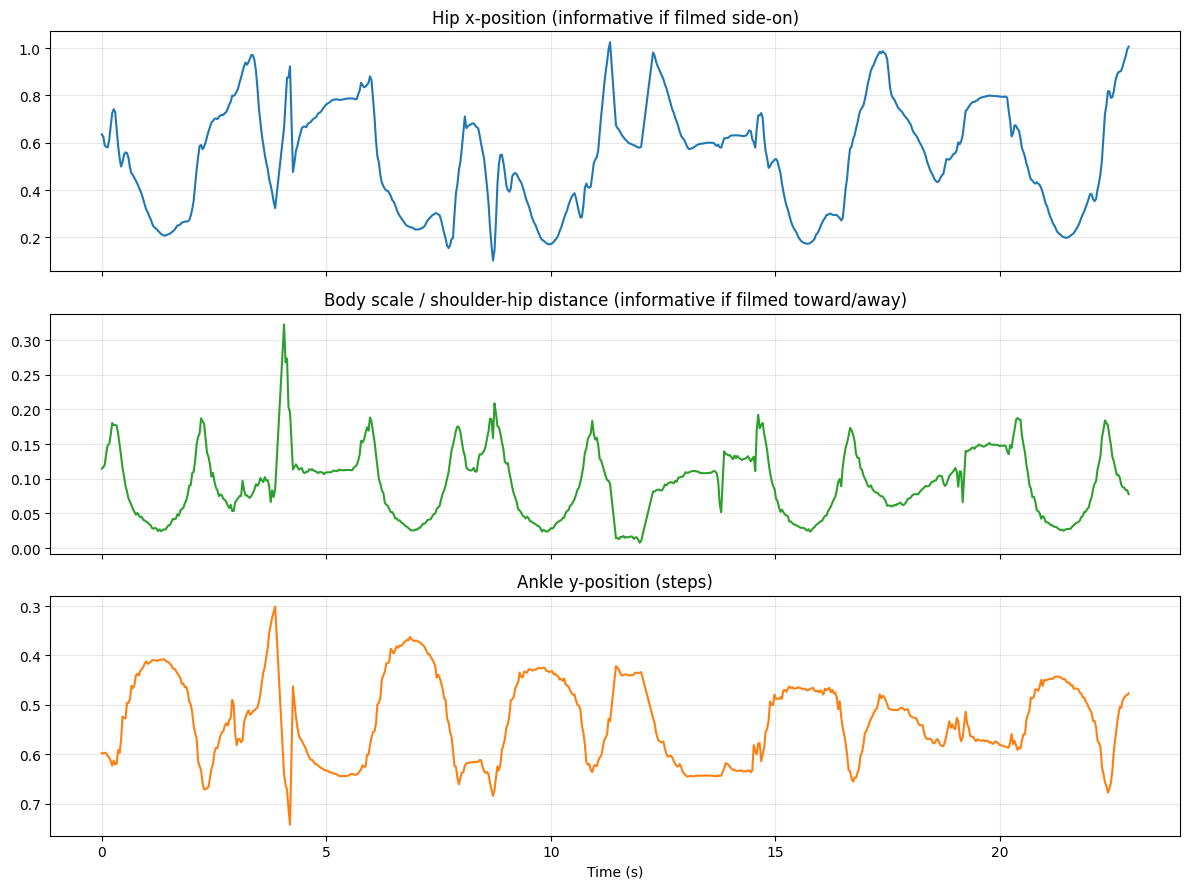

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(timestamps_sec, hip_x_series, color='tab:blue')
axes[0].set_title('Hip x-position (informative if filmed side-on)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(timestamps_sec, body_scale_series, color='tab:green')
axes[1].set_title('Body scale / shoulder-hip distance (informative if filmed toward/away)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(timestamps_sec, ankle_y_series, color='tab:orange')
axes[2].set_title('Ankle y-position (steps)')
axes[2].set_xlabel('Time (s)')
axes[2].invert_yaxis()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
fig.savefig('yoyo_trajectories_report.png', dpi=200, bbox_inches='tight')
from google.colab import files
files.download('yoyo_trajectories_report.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Run shuttle/rest segmentation — tune thresholds here if needed

This calls the same `_segment_movement()` the production module uses. It
classifies every frame as **moving** (real sprint) or **paused**, using
smoothed left-right velocity against `ct.MOVING_VELOCITY_THRESHOLD` — not
peak detection — so standing at a cone isn't mistaken for part of a run.

**v2.2 update:** a real sprint frame being labeled RESTING was traced to
the segmentation itself (not the overlay) - noisy body_scale/hip_x from
running gait was faking turn-points mid-sprint, and a rest-walk flowing
straight into the next sprint (a speed change, not a direction change) had
no turn-point at all between them. Both are fixed in the module now
(`TURN_POINT_SMOOTH_WINDOW_SEC`, `TURN_POINT_MIN_SPACING_SEC`,
`_segment_rate`, `_refine_span`) and were checked against synthetic
noisy-gait test signals before shipping.

**If legs still get missed, merged, or split wrong on your footage**, these
are the knobs to adjust (all defined at the top of `cadence_tracker.py`):
- `LEG_AVG_RATE_THRESHOLD` — raise if rest-walk jitter gets counted as
  running; lower if a real sprint gets mistaken for resting.
- `MIN_LEG_DISPLACEMENT` — raise if small camera-jitter blips get counted
  as legs/turn-points.
- `MIN_REST_DURATION_SEC` — raise if the brief cone-turn pause is getting
  mistaken for the real 10s recovery rest.
- `TURN_POINT_MIN_SPACING_SEC` — raise if gait wobble is still faking a
  turn-point mid-sprint; lower if two genuinely close-together real turns
  are getting merged into one.

Edit the values directly in the module cell above (step 3), then re-run
from that cell down.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

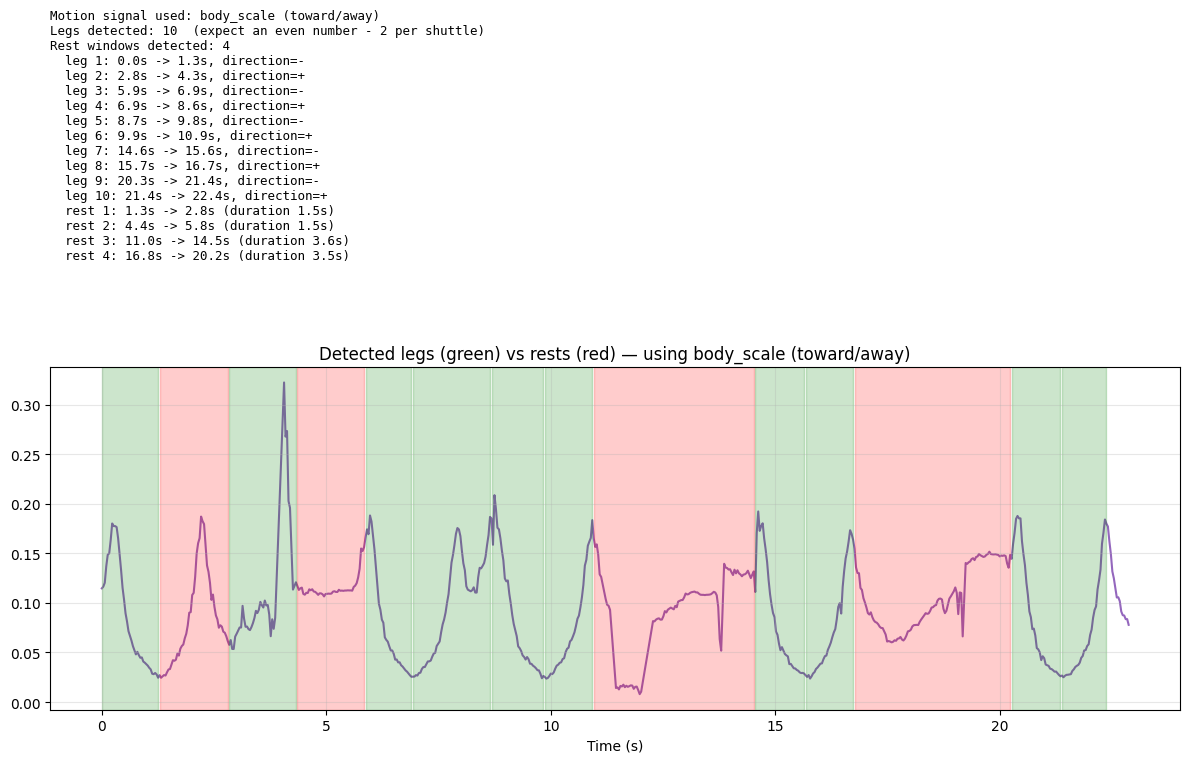

In [14]:
import matplotlib.pyplot as plt

signal = tracker._select_motion_signal()
legs, rests = tracker._segment_movement(signal, timestamps_sec)

lines = [
    f"Motion signal used: {tracker._last_signal_used}",
    f"Legs detected: {len(legs)}  (expect an even number - 2 per shuttle)",
    f"Rest windows detected: {len(rests)}",
]
for i, (s, e, direction) in enumerate(legs):
    lines.append(f"  leg {i+1}: {timestamps_sec[s]:.1f}s -> {timestamps_sec[e-1]:.1f}s, direction={'+' if direction > 0 else '-'}")
for i, (s, e) in enumerate(rests):
    dur = timestamps_sec[e-1] - timestamps_sec[s]
    lines.append(f"  rest {i+1}: {timestamps_sec[s]:.1f}s -> {timestamps_sec[e-1]:.1f}s (duration {dur:.1f}s)")
stats_text = "\n".join(lines)

fig = plt.figure(figsize=(12, 4 + 0.22 * len(lines)))
gs = fig.add_gridspec(2, 1, height_ratios=[0.22 * len(lines), 4])

ax_text = fig.add_subplot(gs[0])
ax_text.axis('off')
ax_text.text(0, 1, stats_text, fontsize=9, family='monospace', va='top', ha='left')

ax_plot = fig.add_subplot(gs[1])
ax_plot.plot(timestamps_sec, signal, color='tab:purple', zorder=1)
for s, e, _ in legs:
    ax_plot.axvspan(timestamps_sec[s], timestamps_sec[e-1], color='green', alpha=0.2)
for s, e in rests:
    ax_plot.axvspan(timestamps_sec[s], timestamps_sec[e-1], color='red', alpha=0.2)
ax_plot.set_title(f'Detected legs (green) vs rests (red) — using {tracker._last_signal_used}')
ax_plot.set_xlabel('Time (s)')
ax_plot.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig('yoyo_segmentation_report.png', dpi=200, bbox_inches='tight')

from google.colab import files
files.download('yoyo_segmentation_report.png')

plt.show()

## 9. Build the final JSON report

This calls the same `finalize()` the live backend calls — pairs legs into
shuttles, computes per-shuttle cadence and the fatigue trend, checks rest
compliance, looks up real distance/speed for the reported score, and
compares against the target benchmark. This is the exact structure to send
to Groq for tip generation.

In [10]:
import json

manual_input = {"yoyo_level": yoyo_level}
if measured_test_duration_sec is not None:
    manual_input["measured_test_duration_sec"] = measured_test_duration_sec

report = tracker.finalize(
    manual_input=manual_input,
    reference={"target_board": target_board, "target_yoyo_score": target_yoyo_score},
)
tracker.close()

print(json.dumps(report, indent=2))

with open('yoyo_report_sample.json', 'w') as f:
    json.dump(report, f, indent=2)
print("\nSaved to yoyo_report_sample.json")


{
  "generated_at": "2026-09-06T15:20:34.640796+00:00",
  "manual_input": {
    "yoyo_level": "16.3",
    "duration_cross_check": null
  },
  "level_reference": {
    "speed_kmh": 15.5,
    "distance_m": 1200,
    "cumulative_shuttle_number": 30,
    "note": null
  },
  "shuttle_count_cross_check": {
    "expected_from_reported_score": 30,
    "detected_in_video": 5,
    "note": "video shuttle count is lower than expected - clip likely starts mid-test or misses some reps"
  },
  "pose_detection": {
    "frames_processed": 694,
    "frames_with_pose": 675,
    "frames_without_pose": 19
  },
  "shuttle_metrics": {
    "motion_signal_used": "body_scale (toward/away)",
    "shuttles_detected": 5,
    "partial_leg_at_end": false,
    "direction_anomaly_detected": false,
    "cadence_trend": "declining",
    "shuttles": [
      {
        "shuttle_index": 1,
        "out_leg": {
          "steps": 4,
          "cadence": 3.19,
          "duration_sec": 1.25
        },
        "back_leg": {
  

## 10. Generate an annotated demo video (skeleton overlay + shuttle state)

Re-runs pose detection over the video and draws:
- the MediaPipe skeleton on the player
- a status label showing **RUNNING** / **RESTING** / **TURN** for the
  current frame, plus which shuttle number is in progress

Useful for showing judges/teammates the pipeline actually working, without
them having to read a JSON file. Re-encoded with `ffmpeg` at the end for
WhatsApp compatibility.

In [11]:
# mediapipe.solutions (legacy drawing_utils) is deprecated/removed in newer mediapipe builds.
# Standard 33-point MediaPipe Pose connections (index pairs), hardcoded since
# mp_solutions.pose.POSE_CONNECTIONS is no longer importable.
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
POSE_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 7), (0, 4), (4, 5), (5, 6), (6, 8),
    (9, 10), (11, 12), (11, 13), (13, 15), (15, 17), (15, 19), (15, 21), (17, 19),
    (12, 14), (14, 16), (16, 18), (16, 20), (16, 22), (18, 20),
    (11, 23), (12, 24), (23, 24), (23, 25), (25, 27), (27, 29), (29, 31), (27, 31),
    (24, 26), (26, 28), (28, 30), (30, 32), (28, 32),
]

def draw_pose_landmarks(frame, landmarks, w, h):
    points = [(int(lm.x * w), int(lm.y * h)) for lm in landmarks]
    for a, b in POSE_CONNECTIONS:
        if a < len(points) and b < len(points):
            cv2.line(frame, points[a], points[b], (0, 200, 255), 2)
    for x, y in points:
        cv2.circle(frame, (x, y), 4, (0, 255, 0), -1)
    return frame

def frame_state_label(det_idx, legs, rests):
    """Which state + shuttle number a given DETECTED-frame index falls into,
    for the on-screen overlay. Purely cosmetic - doesn't affect the JSON
    report. IMPORTANT: `legs`/`rests` are index ranges into the series of
    frames WHERE A POSE WAS DETECTED (see section 6 - 'Processed X frames,
    Y frames with a detected pose'). So this must be given a detected-frame
    counter, NOT the raw video frame number - the two diverge whenever any
    frame loses its pose, and every divergence shifts all later labels."""
    for i, (s, e, _) in enumerate(legs):
        if s <= det_idx < e:
            shuttle_num = (i // 2) + 1
            return f"RUNNING (shuttle {shuttle_num})"
    for s, e in rests:
        if s <= det_idx < e:
            return "RESTING"
    return "TURN"

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"Could not open video file: {video_path}")

frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
# v2.1: recompute fps locally so this cell works even if section 6 wasn't
# run in this session (e.g. partial re-run after a runtime restart).
fps_annot = cap.get(cv2.CAP_PROP_FPS) or 30.0
frame_interval_ms_annot = int(1000 / fps_annot)

raw_output_path = 'yoyo_annotated_raw.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(raw_output_path, fourcc, fps_annot, (frame_w, frame_h))

landmarker2 = mp_vision.PoseLandmarker.create_from_options(
    mp_vision.PoseLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path='pose_landmarker_lite.task'),
        running_mode=mp_vision.RunningMode.VIDEO,
        num_poses=1,
    )
)

frame_idx = 0   # counts ALL video frames - drives the detection timestamp
det_idx = 0     # counts frames WHERE A POSE WAS FOUND - drives the label

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
    result = landmarker2.detect_for_video(mp_image, frame_idx * frame_interval_ms_annot)

    if result.pose_landmarks:
        frame = draw_pose_landmarks(frame, result.pose_landmarks[0], frame_w, frame_h)
        label = frame_state_label(det_idx, legs, rests)
        det_idx += 1
    else:
        # Honest label for dropped frames - previously these got whatever
        # label the misaligned index happened to land on.
        label = "NO POSE"

    cv2.rectangle(frame, (10, 10), (360, 55), (0, 0, 0), -1)
    cv2.putText(frame, label, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)

    writer.write(frame)
    frame_idx += 1

cap.release()
writer.release()
landmarker2.close()
print(f"Wrote {raw_output_path} ({det_idx} of {frame_idx} frames had a detected pose)")

Wrote yoyo_annotated_raw.mp4 (675 of 694 frames had a detected pose)


### Re-encode for WhatsApp compatibility

OpenCV's `mp4v` output often won't preview/play correctly on WhatsApp or some
phones. Re-encoding with `ffmpeg` to H.264 video in a standard MP4 container
fixes that and keeps the file small.

In [12]:
final_output_path = 'yoyo_demo_whatsapp.mp4'

!ffmpeg -y -i {raw_output_path} -c:v libx264 -profile:v baseline -level 3.0 -pix_fmt yuv420p -movflags +faststart -crf 26 -preset veryfast -an {final_output_path}

import os
size_mb = os.path.getsize(final_output_path) / (1024 * 1024)
print(f"\nFinal WhatsApp-ready video: {final_output_path} ({size_mb:.1f} MB)")

from google.colab import files
files.download(final_output_path)


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Next steps

1. Check the plots in step 7-8 — legs (green) should line up with the
   sprints you'd count by eye, rests (red) with the ~10s recovery walks.
2. Tune `MOVING_VELOCITY_THRESHOLD` / `MIN_LEG_DISPLACEMENT` /
   `MIN_REST_DURATION_SEC` in the module cell (step 3) if segmentation looks
   off, then re-run from there.
3. `YOYO_IR1_LEVEL_TABLE` uses the **YYIR1** protocol (starts at 10 km/h) -
   confirmed this is correct for BCCI (multiple sources agree BCCI, along
   with most cricket boards, uses YYIR1; YYIR2 - starting at 13 km/h - is
   reserved for sports needing heavier anaerobic testing). Table covers
   scores up to `23.8` (elite range); anything beyond that returns an
   explicit 'outside tabulated range' note rather than a guess.
4. Once this is reliable on real footage, `cadence_tracker.py` (written in
   step 3) is already the exact module the FastAPI websocket handler should
   import — no further porting needed.
5. Send the JSON from step 9 to Groq with a prompt asking for specific
   per-shuttle pacing/fatigue tips referencing these exact numbers.
